# Methodology: Find Gamma using random regions

**Goal:**
Find an optimal selection of gamma by choosing 100 random 1kb regions of the genome.

**Procedure**
1. Find the optimal gamma value for a random 1kb region of the genome. Time how long this takes. 
2. Determine if this process should be done inside this notebook or on the cluster.


In [1]:
# Preamble, notebook setup and imports
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from src.GenomeDeconvolution import GenomeDeconvolution

genome_deconvolution = GenomeDeconvolution(save_dir=None)

genome_10K_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')

chrom = 1
span = (10000, 11000)

print(f"Deconvolving chr{chrom}, {span[0]}-{span[1]}")
genome_deconvolution.load_chrom_span(chrom, span)

Deconvolving chr1, 10000-11000
Loading chromosome reads: 1
Applying a normalization for length distribution
Loading chromosome reads: 1
Applying a normalization for length distribution
Adding a deconvolution offset to G: 1


In [9]:
genome_deconvolution.combined_model.deconvolve_find_optimal_gamma()

Adding a deconvolution offset to G: 1
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.2102
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.2902, rate = 6.6
  ...   gm = 0.0050, rn = 1.3445, rate = 11.10, time = 00:09:07.968
  ...   gm = 0.0026, rn = 1.3219, rate = 9.23, time = 00:12:27.066
  ...   gm = 0.0013, rn = 1.3070, rate = 8.00, time = 00:15:46.337
  ...  search right, rn_goal = 1.6943, rate = 40.0
  ... rn range: [1.3070, 1.3761]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 1.3070, rate = 8.00, time = 00:22:33.274
  ...   gm = 0.0022, rn = 1.3174, rate = 8.86, time = 00:25:55.594
  ...   gm = 0.0031, rn = 1.3272, rate = 9.66, time = 00:29:15.734
  ...   gm = 0.0039, rn = 1.3354, rate = 10.35, time = 00:32:41.294
  ...   gm = 0.0048, rn = 1.3421, rate = 10.90, time = 00:36:03.086
  ...   gm = 0.0057, rn = 1.3488, rate = 11.45,

In [78]:

from src.sgd import get_chromosome_length

np.random.seed(123)
rows = []

# Generate a set of random 500 1kb windows of the genome
for i in range(500):
    chrom = np.random.choice(np.arange(1, 17))
    chrom_len = get_chromosome_length(chrom)

    # (avoid first 20kb and last 20kb of a chromosome where there is low read coverage)
    padding = 20000
    window_len = 1000
    random_start =np.random.choice(np.arange(padding, chrom_len-padding-window_len))

    random_end = random_start+window_len

    span = (random_start, random_end)
    row = (chrom, span[0], span[1])
    rows.append(row)


In [79]:
random_windows = pd.DataFrame(rows, columns=['chrom', 'start', 'end'])
random_windows.to_csv('data/reference_data/sacCer3_genome_500_random_1k_windows.csv')


In [26]:
from glob import glob

rows = []
for csv_path in glob('output/find_gamma_100_1k_2024_11_14/data/gamma/*'):
    gamma_row = pd.read_csv(csv_path).rename(columns={'Unnamed: 0': 
        'index'}).set_index('index')
    rows.append(gamma_row.iloc[0])


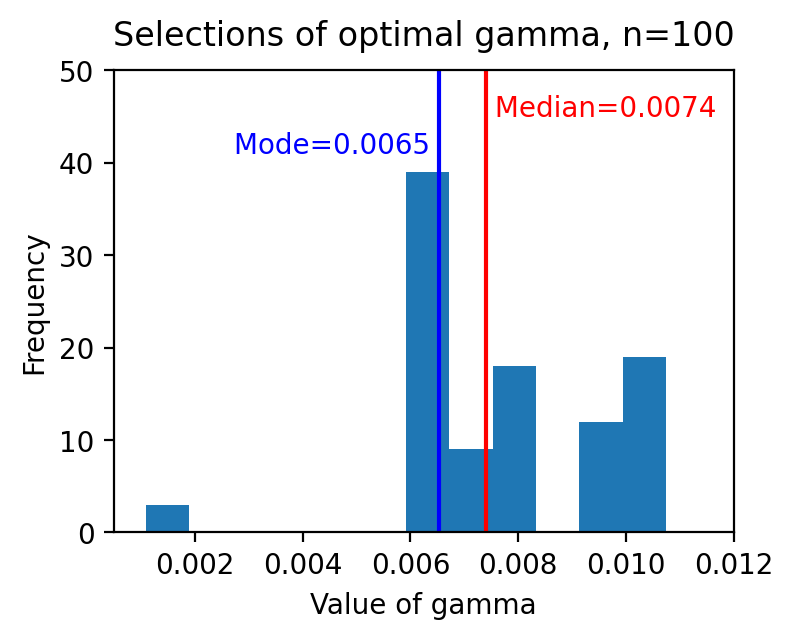

In [77]:
from src.figure_configs import save_figure_for_paper

gamma_df = pd.DataFrame(rows)
gamma_vals = gamma_df['gamma']
median_gamma = gamma_vals.median()
mode_gamma = gamma_vals.mode()[0]

plt.figure(figsize=(4, 3))
plt.hist(gamma_df['gamma'], bins=12)
plt.title(f"Selections of optimal gamma, n={len(rows)}", pad=9)
plt.xlabel("Value of gamma")
plt.ylabel("Frequency")
plt.axvline(median_gamma, label='Median', c='red')
plt.text(median_gamma, 45, f" Median={median_gamma:.4f} ", c='red', ha='left')

plt.axvline(mode_gamma, label='Mode', c='blue')
plt.text(mode_gamma, 41, f"Mode={mode_gamma:.4f} ", c='blue', ha='right')

plt.ylim(0, 50)
plt.xlim(0.0005, 0.012)

save_figure_for_paper("output/figures/Methods/Find_optimal_gamma.png")